# LINMA2470 – Stochastic Modelling – Project Part II

**Group Member:** Lore Lernoux, Anthony Richelle, Brieuc Dallemagne, Tessa Rouvez   
**NOMA:** 77562000, 39962400, 77122100, 37782100 

This notebook presents our implementation for Part II of the LINMA2470 project.

In [2]:
using Pkg
# Pkg.add("Statistics")
#Pkg.add("Plots")
# Pkg.add("POMDPs")
# Pkg.add("POMDPTools")
# Pkg.add("QuickPOMDPs")
# Pkg.add("DiscreteValueIteration")
# Pkg.add("TabularTDLearning")
# Pkg.add("Distributions")
# Pkg.add("JuMP")
# Pkg.add("GLPK")
# Pkg.add("DataFrames")
# Pkg.add("Plots")
# Pkg.add("StatsPlots")

Imports :

In [3]:
using POMDPs
using QuickPOMDPs
using TabularTDLearning
using POMDPTools
using Distributions
using Random
using Statistics
using Serialization
using DataFrames
using StatsPlots 
using Plots

## Formulation of the problem

First, let's start with the generative function. The problem was modeled as follows :

- First, check if the store need new bikes from the warehouse. If they are not enough bikes to satisfy both shops, send them to the one with the least amount of bikes. If there is an equality prioritize shop 2 has it has lower holding costs.
- When a store order bikes, they arrive at 9 am right before people start coming into the shop. Transport costs are 20. They are only paid if bikes are delivered. 
- The holding costs are payed on the bike in store during the night, so they simply depend on the current state.
- If some stores have unmet demand, the bikes are ordered online to the warehouse at an additional cost of 10. If the warehouse is empty, the penality is 50 instead as we miss a sale.
- The Warhouse can order new bikes at the factory. They arrive the following day at 9 am.
- The function also has an option to record calls and rewards, this is to allow us to plot the learning curves.


In [4]:
global total_steps = 0
global max_steps_per_episode = 0
global num_total_episodes = 0
global episode_rewards = zeros(num_total_episodes)
global discount_factor = 0.99

function setup_tracking(;num_episodes, max_steps, gamma)
    global total_steps = 0
    global max_steps_per_episode = max_steps
    global num_total_episodes = num_episodes
    global episode_rewards = zeros(num_episodes)
    global discount_factor = gamma
end

function generative_function(s, a, rng, record=true; demand=(-1, -1))
    global total_steps, max_steps_per_episode, num_total_episodes, episode_rewards, discount_factor
    i1, i2, w = s
    o1, o2, c1 = a

    # Now let's compute supply for the next day
    ord1, ord2 = min(20 - i1, 5), min(20 - i2, 5)
    req1, req2 = o1 * ord1, o2 * ord2

    # Check if we have to split this between stores
    if req1 + req2 > w 
        sup1, sup2 = 0, 0
        if i1 < i2 
            sup1 = min(ord1, w)
        else # This slightly favors store 2 with less holding costs 
            sup2 = min(ord2, w)
        end
    else
        sup1, sup2 = req1, req2
    end

    # Holding costs are paid during the night
    hold_cost = 2 * min(i1, 10) + 4 * max(i2 - 10, 0) + 2 * i2 + 1 * w

    # Cost of transport, adapted if only one delivery
    trans_cost = 20 * (sup1 > 0) + 20 * (sup2 > 0)

    # Stocks at 9am
    tw = min(max(w - sup1 - sup2, 0) + 10 * c1, 20)
    ti1 = i1 + sup1
    ti2 = i2 + sup2

    if demand[1] == -1 d1 = rand(rng, 0:7) else d1 = demand[1] end
    if demand[2] == -1 d2 = rand(rng, 0:7) else d2 = demand[2] end

    # Compute the new states
    ni1 = max(ti1 - d1, 0)
    ni2 = max(ti2 - d2, 0)

    # Holding costs are paid during the night
    hold_cost = 2 * min(i1, 10) + 4 * max(i2 - 10, 0) + 2 * i2 + 1 * max(w - sup1 - sup2, 0)

    # Compute the possible home delivery / lost sales
    leftsales = max(d1 - ti1, 0) + max(d2 - ti2, 0)
    instore = d1 + d2 - leftsales
    delivery = min(leftsales, tw)
    losts = leftsales - delivery
    penality = 10 * delivery + 50 * losts
    r = -(hold_cost + trans_cost + penality)

    # Computation of the learning curve
    if record
        current_episode = div(total_steps, max_steps_per_episode) + 1
        current_step = mod(total_steps, max_steps_per_episode) + 1
        episode_rewards[current_episode] += r * (discount_factor)^(current_step - 1)
        total_steps += 1
    end
    
    return (
        sp=(ni1, ni2, tw - delivery), 
        r=r, 
        sales=(instore, delivery, losts),
        costs=(hold_cost, trans_cost, penality))
end

bike_inventory_mdp = QuickMDP(
    generative_function,
    states = [(i1, i2, w) for i1 in 0:20, i2 in 0:20, w in 0:20],
    actions = [(o1, o2, c1) for o1 in (0,1), o2 in (0,1), c1 in (0,1)],
    discount = 0.99,
    initialstate = [(10,10,10)]
)

QuickMDP{Base.UUID("c7567bd3-527d-49c1-a4e6-d2038d3dd678"), Tuple{Int64, Int64, Int64}, Tuple{Int64, Int64, Int64}, @NamedTuple{stateindex::Dict{Tuple{Int64, Int64, Int64}, Int64}, isterminal::Bool, actionindex::Dict{Tuple{Int64, Int64, Int64}, Int64}, initialstate::Vector{Tuple{Int64, Int64, Int64}}, gen::typeof(generative_function), states::Array{Tuple{Int64, Int64, Int64}, 3}, actions::Array{Tuple{Int64, Int64, Int64}, 3}, discount::Float64}}((stateindex = Dict((19, 5, 6) => 2771, (6, 13, 14) => 6454, (20, 16, 1) => 798, (3, 9, 8) => 3721, (0, 2, 19) => 8422, (16, 15, 16) => 7388, (14, 12, 1) => 708, (11, 13, 15) => 6900, (16, 5, 3) => 1445, (18, 6, 19) => 8524…), isterminal = false, actionindex = Dict((0, 0, 0) => 1, (1, 1, 1) => 8, (1, 1, 0) => 4, (0, 1, 1) => 7, (0, 1, 0) => 3, (1, 0, 1) => 6, (1, 0, 0) => 2, (0, 0, 1) => 5), initialstate = [(10, 10, 10)], gen = Main.generative_function, states = [(0, 0, 0) (0, 1, 0) … (0, 19, 0) (0, 20, 0); (1, 0, 0) (1, 1, 0) … (1, 19, 0) (1, 2

Here are the functions interfacing TabularTDLearning for the learning process, these can take a very long time to run, this is why we serialize the outputs into files so that we can later reuse the data without having to compute everything again.

We choose $\alpha=0.01$ and $\epsilon=0.01$ to ensure that we would have somewhat stable results. We consider that they are $21^3=9261$ states and they are 3 possible actions : each store can order bikes, and the warehouse can order new bikes. This gives us $8\cdot 9261=74088$ entries in our Q table. The Q table is thus very big and we will use very large number of iterations.

In [4]:

function comp_q_learning(; α::Float64, ε::Float64, num_episodes::Int, max_steps::Int)
    setup_tracking(num_episodes=num_episodes, max_steps=max_steps, gamma=discount(bike_inventory_mdp))
    solver = QLearningSolver(
        exploration_policy = EpsGreedyPolicy(bike_inventory_mdp, ε),
        learning_rate = α,
        n_episodes = num_episodes,
        max_episode_length = max_steps,
        eval_every = 2 * num_episodes,
        n_eval_traj = 0,
    )
    return solve(solver, bike_inventory_mdp)
end

function comp_sarsa(; α::Float64, ε::Float64, num_episodes::Int, max_steps::Int)
    setup_tracking(num_episodes=num_episodes, max_steps=max_steps, gamma=discount(bike_inventory_mdp))
    solver = SARSASolver(
        exploration_policy = EpsGreedyPolicy(bike_inventory_mdp, ε),
        learning_rate = α,
        n_episodes = num_episodes,
        max_episode_length = max_steps,
        eval_every = 2 * num_episodes,
        n_eval_traj = 0,
    )
    return solve(solver, bike_inventory_mdp)
end

Random.seed!(1234)
α = 0.01
ε = 0.01
num_episodes = 5000
max_steps = 1000000

q_learning_solver = comp_q_learning(α=α, ε=ε, num_episodes=num_episodes, max_steps=max_steps)
serialize("ql_learning_curve.jls", episode_rewards)
serialize("q_learning_solver.jls", q_learning_solver)

sarsa_solver = comp_sarsa(α=α, ε=ε, num_episodes=num_episodes, max_steps=max_steps)
serialize("sarsa_solver.jls", sarsa_solver)
serialize("sarsa_learning_curve.jls", episode_rewards)


40000

Here is the code to desirialize the results of the Q-Learning and Sarsa algorithms

In [5]:
q_learning_solver = deserialize("q_learning_solver.jls")
sarsa_solver = deserialize("sarsa_solver.jls")

ql_learning_curve = deserialize("ql_learning_curve.jls")
sarsa_learning_curve = deserialize("sarsa_learning_curve.jls")

5000-element Vector{Float64}:
 -15981.606086718988
  -5785.267693404474
  -6514.356536277064
  -6221.474471381767
  -6279.860049185899
  -6086.724395085306
  -6015.847265848987
  -6870.694879726539
  -6606.022024928777
  -5901.612995982239
  -5743.219675896437
  -5905.991250429816
  -6505.835484721876
      ⋮
  -4936.375047348012
  -4657.379161006541
  -4586.178971028147
  -4644.423823771404
  -4769.210288995311
  -4685.511892556897
  -4740.955218490124
  -4773.147439429923
  -4668.421781433261
  -4675.402363761972
  -4557.924091321609
  -4787.2252688930475

We can also plot the learning curves recorded during the training : 

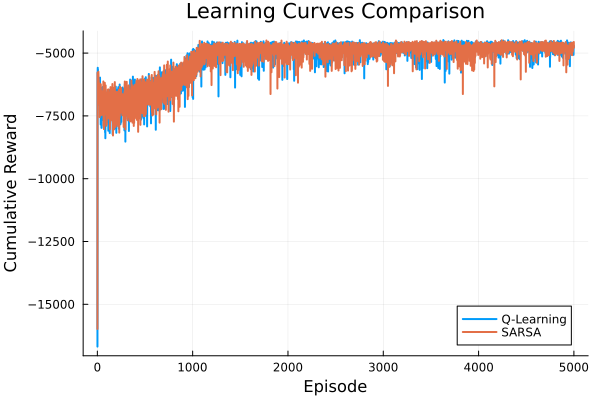

In [6]:
ep = 1:length(ql_learning_curve)

plot(
    ep, ql_learning_curve,
    label = "Q-Learning",
    lw = 2,
    xlabel = "Episode",
    ylabel = "Cumulative Reward",
    title = "Learning Curves Comparison",
    grid = true
)

plot!(
    ep, sarsa_learning_curve,
    label = "SARSA",
    lw = 2
)

Now let's do some statistical analysis on the different learned policies and compare them to the heuristic policy. The procedure is as follows : we compute the results of n_trials simulations of the policy and then analyze the given rewards. The relevant statisical parameters we computed are :
- The mean reward and it's 95% confidence interval (CI95)
- The std deviation on the reward
- The minimum reward among all the simulations
- The maximum reward among all the simulations

These parameters can help us better understand the types of strategies that were learned.

In [7]:
function heuristic_policy(s)
    i1, i2, w = s
    o1 = i1 < 7 ? 1 : 0
    o2 = i2 < 7 ? 1 : 0
    out1 = o1 * min(20 - i1, 5)
    out2 = o2 * min(20 - i2, 5)
    c1 = (w - out1 - out2) < 10 ? 1 : 0
    return (o1, o2, c1)
end

function learned_policy(policy::ValuePolicy)
    return s -> action(policy, s)
end

function simulate_episode(policy_fn, initial_state, rng, num_steps)
    s = initial_state
    state_list = []

    holding_cost = 0.0
    transport_cost = 0.0
    penality = 0.0

    demand_stats = Dict(:instore => 0, :delivery => 0, :losts => 0)

    dis = 1.0
    for _ in 1:num_steps
        a = policy_fn(s)
        result = generative_function(s, a, rng, false)
        push!(state_list, s)
        s = result.sp

        holding_cost += dis * result.costs[1]
        transport_cost += dis * result.costs[2]
        penality += dis * result.costs[3]
        dis *= discount(bike_inventory_mdp)

        demand_stats[:instore] += result.sales[1]
        demand_stats[:delivery] += result.sales[2]
        demand_stats[:losts] += result.sales[3]
    end
    return (
        total=-(holding_cost + transport_cost + penality), 
        h=holding_cost, t=transport_cost, p=penality, 
        demand=demand_stats, states=state_list)
end

function compute_state_heatmap(costs)
    heatmap_matrix = zeros(length(0:20), length(0:20))
    total = 0
    for c in costs
        for s in c.states
            heatmap_matrix[s[1] + 1, s[2] + 1] += 1
            total += 1
        end
    end
    return heatmap_matrix / total * 100
end

function compute_stats(costs)
    h_vals = [c.h for c in costs]
    t_vals = [c.t for c in costs]
    p_vals = [c.p for c in costs]
    total_vals = [c.total for c in costs]

    instore = [c.demand[:instore] for c in costs]
    delivery = [c.demand[:delivery] for c in costs]
    losts = [c.demand[:losts] for c in costs]

    mean_instore = mean(instore)
    mean_delivery = mean(delivery)
    mean_losts = mean(losts)
    mean_total = mean_instore + mean_delivery + mean_losts

    avg_i1_vals = [mean(s[1] for s in c.states) for c in costs]
    avg_i2_vals = [mean(s[2] for s in c.states) for c in costs]
    avg_w_vals = [mean(s[3] for s in c.states) for c in costs]

    μ = mean(total_vals)
    σ = std(total_vals)
    ci95 = 1.96 * σ / sqrt(length(total_vals))

    return (
        total = (mean=μ, std=σ, min=minimum(total_vals), max=maximum(total_vals), ci95=ci95),
        holding = mean(h_vals),
        transport = mean(t_vals),
        penality = mean(p_vals),
        percent_served = mean_instore / mean_total * 100,
        percent_delivered = mean_delivery / mean_total * 100,
        percent_lost = mean_losts / mean_total * 100,
        avg_i1= mean(avg_i1_vals),
        avg_i2= mean(avg_i2_vals),
        avg_w= mean(avg_w_vals),
        heatmap = compute_state_heatmap(costs)
    )
end


function compare_policies(q_pol::ValuePolicy, sarsa_pol::ValuePolicy, n_trials::Int, max_steps::Int; seed=1234)
    rng = MersenneTwister(seed)
    init_state = (10, 10, 10)

    pol_q = learned_policy(q_pol)
    pol_sarsa = learned_policy(sarsa_pol)

    costs_q = [simulate_episode(pol_q, init_state, rng, max_steps) for _ in 1:n_trials]
    costs_sarsa = [simulate_episode(pol_sarsa, init_state, rng, max_steps) for _ in 1:n_trials]
    costs_heur = [simulate_episode(heuristic_policy, init_state, rng, max_steps) for _ in 1:n_trials]

    stats_q = compute_stats(costs_q)
    stats_sarsa = compute_stats(costs_sarsa)
    stats_heur = compute_stats(costs_heur)

    return (stats_q, stats_sarsa, stats_heur)
end

stats_q, stats_sarsa, stats_heur = compare_policies(q_learning_solver, sarsa_solver, 1000, 10000)

((total = (mean = -4740.491675314701, std = 141.78229080544213, min = -5727.654091983659, max = -4465.290338110338, ci95 = 8.787757428102307), holding = 1530.872695974746, transport = 2470.0627682774907, penality = 739.556211062463, percent_served = 89.11026021693466, percent_delivered = 10.885554034611353, percent_lost = 0.004185748453981161, avg_i1 = 2.7394454, avg_i2 = 2.8428104999999997, avg_w = 9.4474439, heatmap = [8.900030000000001 3.23494 … 9.999999999999999e-6 0.0; 2.83605 1.16878 … 0.0 0.0; … ; 4.9999999999999996e-5 2.9999999999999997e-5 … 0.0 1.9999999999999998e-5; 3.9999999999999996e-5 0.0 … 0.0 0.0]), (total = (mean = -4714.881182079178, std = 104.57198660360115, min = -5421.76042049125, max = -4475.73908766474, ci95 = 6.481438879473501), holding = 1538.6682326165644, transport = 2484.431932493698, penality = 691.7810169689154, percent_served = 89.87299585625496, percent_delivered = 10.123753704982263, percent_lost = 0.003250438762798138, avg_i1 = 2.8300589, avg_i2 = 2.875

In [8]:
df_rewards = DataFrame(
    Policy = ["Q-learning", "SARSA", "Heuristic"],
    Mean_Reward = [stats_q.total.mean, stats_sarsa.total.mean, stats_heur.total.mean],
    Std_Reward = [stats_q.total.std, stats_sarsa.total.std, stats_heur.total.std],
    CI95 = [stats_q.total.ci95, stats_sarsa.total.ci95, stats_heur.total.ci95],
    Min_Reward = [stats_q.total.min, stats_sarsa.total.min, stats_heur.total.min],
    Max_Reward = [stats_q.total.max, stats_sarsa.total.max, stats_heur.total.max]
)
display(df_rewards)

Row,Policy,Mean_Reward,Std_Reward,CI95,Min_Reward,Max_Reward
,String,Float64,Float64,Float64,Float64,Float64
1,Q-learning,-4740.49,141.782,8.78776,-5727.65,-4465.29
2,SARSA,-4714.88,104.572,6.48144,-5421.76,-4475.74
3,Heuristic,-5506.38,74.3015,4.60526,-5760.24,-5264.79


From this table, it is clear that SARSA leads to the best policy (not by far). Q-Learning has more variability than the other (largest standart devivation) this could explain why it is slightly worse as the max reward is not better but the the min reward is much worse.

In [9]:
df_costs = DataFrame(
    Policy = ["Q-learning", "SARSA", "Heuristic"],
    Holding_Cost = [stats_q.holding, stats_sarsa.holding, stats_heur.holding],
    Transport_Cost = [stats_q.transport, stats_sarsa.transport, stats_heur.transport],
    Penalty_Cost = [stats_q.penality, stats_sarsa.penality, stats_heur.penality]
)
display(df_costs)

Row,Policy,Holding_Cost,Transport_Cost,Penalty_Cost
,String,Float64,Float64,Float64
1,Q-learning,1530.87,2470.06,739.556
2,SARSA,1538.67,2484.43,691.781
3,Heuristic,2701.94,2728.55,75.8888


Here, we can see which cost is prefered by each policy. Q-learning is more into risk, i.e. preferring to pay for not selling a bike than holding to much bikes in the stores/warehouse. SARSA tends to do the same but is more conservative. The heuristic policy will really avoid those penalties, but leads to higher holding costs than the RL policies.

In [10]:
df_percentages = DataFrame(
    Policy = ["Q-learning", "SARSA", "Heuristic"],
    Holding_Pct = [100 * stats_q.holding / -stats_q.total.mean,
                    100 * stats_sarsa.holding / -stats_sarsa.total.mean,
                    100 * stats_heur.holding / -stats_heur.total.mean],
    Transport_Pct = [100 * stats_q.transport / -stats_q.total.mean,
                        100 * stats_sarsa.transport / -stats_sarsa.total.mean,
                        100 * stats_heur.transport / -stats_heur.total.mean],
    Penalty_Pct = [100 * stats_q.penality / -stats_q.total.mean,
                    100 * stats_sarsa.penality / -stats_sarsa.total.mean,
                    100 * stats_heur.penality / -stats_heur.total.mean]
)
display(df_percentages)

Row,Policy,Holding_Pct,Transport_Pct,Penalty_Pct
,String,Float64,Float64,Float64
1,Q-learning,32.2935,52.1056,15.6008
2,SARSA,32.6343,52.6934,14.6723
3,Heuristic,49.0693,49.5525,1.3782


The transport costs seem higher than for the heuristic policy but this is just because the other costs are lower. SARSA and Q-Learning even have less transport costs than the heuristic policy, further enhancing cost savings. The big reduction is in holding costs but this causes a slightly higher penality cost.

In [11]:
df_percentages = DataFrame(
    Policy = ["Q-learning", "SARSA", "Heuristic"],
    Percent_Instore = [stats_q.percent_served, stats_sarsa.percent_served, stats_heur.percent_served],
    Percent_Delivered = [stats_q.percent_delivered, stats_sarsa.percent_delivered, stats_heur.percent_delivered],
    Percent_Lost = [stats_q.percent_lost, stats_sarsa.percent_lost, stats_heur.percent_lost]
)
display(df_percentages)

Row,Policy,Percent_Instore,Percent_Delivered,Percent_Lost
,String,Float64,Float64,Float64
1,Q-learning,89.1103,10.8856,0.00418575
2,SARSA,89.873,10.1238,0.00325044
3,Heuristic,98.9128,1.08721,1.57138e-5


Here we see that the RL policies consist in an equilibrium between loosing some sales / doing home deliveries to avoid excessive holding costs. The downside of the heuristic policy is that it is too risk averse and avoids deliveries or lost sales as much as possible. This also shows that the warehouse is almost never empty.

In [ ]:
df_stock = DataFrame(
    Policy = ["Q-learning", "SARSA", "Heuristic"],
    Avg_Bikes_Shop1 = [stats_q.avg_i1, stats_sarsa.avg_i1, stats_heur.avg_i1],
    Avg_Bikes_Shop2 = [stats_q.avg_i2, stats_sarsa.avg_i2, stats_heur.avg_i2],
    Avg_Bikes_Warehouse = [stats_q.avg_w, stats_sarsa.avg_w, stats_heur.avg_w]
)

display(df_stock)

Row,Policy,Avg_Bikes_Shop1,Avg_Bikes_Shop2,Avg_Bikes_Warehouse
,String,Float64,Float64,Float64
1,Q-learning,2.73945,2.84281,9.44744
2,SARSA,2.83006,2.87565,9.64793
3,Heuristic,4.896,4.89817,14.2832


The average number of bikes in shop 1, 2 and in the warehouse are the stocks at the end of the day. Lower stocks can be better for buisness as it means less holding costs. Notice that the RL policies are more aggressive, they will accept having to home deliver some bikes or even missing sales to pay less total costs. On the other hand, the heuristic policy seems to be the policy for maximum safety but it is less efficient.

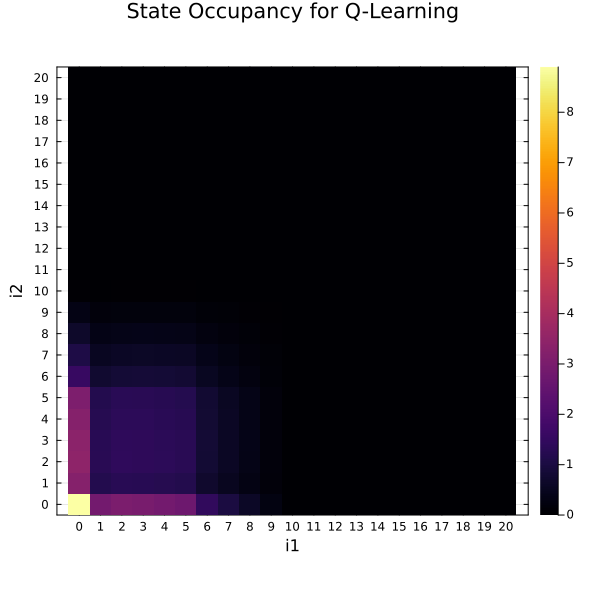

In [13]:
heatmap(
    0:20, 0:20,
    stats_q.heatmap',
    xlabel = "i1",
    ylabel = "i2",
    title = "State Occupancy for Q-Learning",
    cbar = true,
    aspect_ratio = :equal,
    xticks = 0:1:20,
    yticks = 0:1:20,
    framestyle = :box,
    size = (600, 600)
)

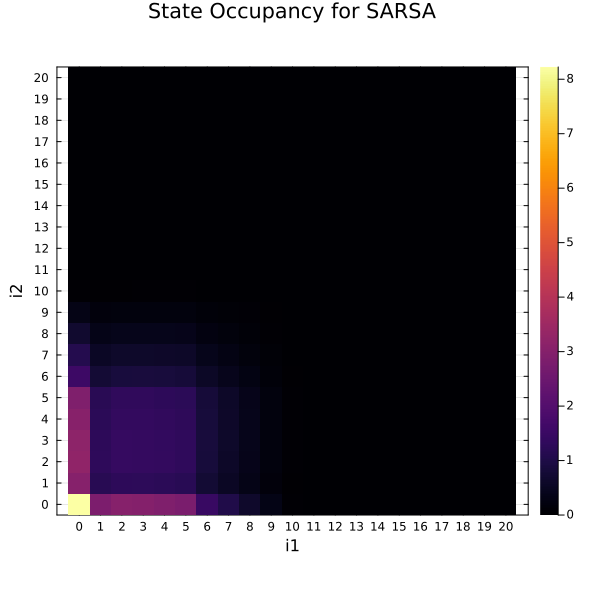

In [14]:

heatmap(
    0:20, 0:20,
    stats_sarsa.heatmap',
    xlabel = "i1",
    ylabel = "i2",
    title = "State Occupancy for SARSA",
    cbar = true,
    aspect_ratio = :equal,
    xticks = 0:1:20,
    yticks = 0:1:20,
    framestyle = :box,
    size = (600, 600)
)

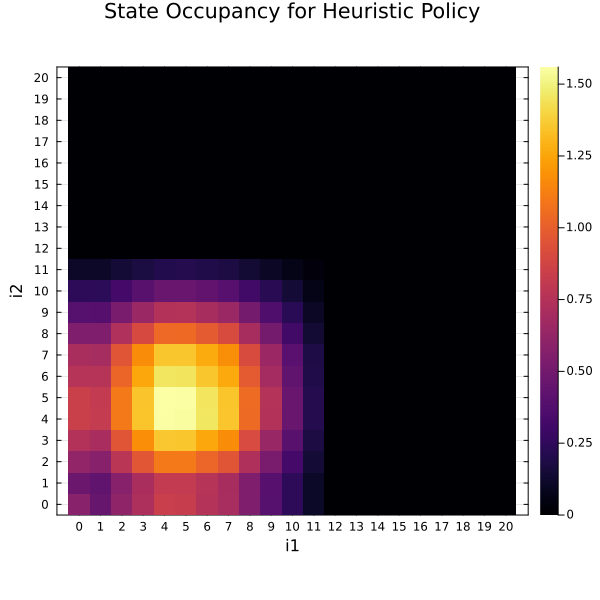

In [15]:

heatmap(
    0:20, 0:20,
    stats_heur.heatmap',
    xlabel = "i1",
    ylabel = "i2",
    title = "State Occupancy for Heuristic Policy",
    cbar = true,
    aspect_ratio = :equal,
    xticks = 0:1:20,
    yticks = 0:1:20,
    framestyle = :box,
    size = (600, 600)
)

Note that the heatmap reprensent the number of bikes at the end of the day. Those three heatmaps confirm what we analyzed before. Indeed, SARSA and Q-learning tend to have no/low amounts of bikes in the stores so that it doesn't have to pay for holding costs. This is not an issue as they can order new bikes and have more bikes than the average demand (which is 3.5) and does not usually end up in missing sales as, even when no bikes are in store, some can be home delivered. On the other hand, the heuristic policy tends to have 5 bikes in each store, sometimes even order new bikes and get 10, which is something the RL policies never do.

We can also compute the steady states probabilities exactly, this will lead to very similar state occupancy map as the simulation but may be usefull to see if some states that should be reached are never reached from our starting point.

In [16]:
using SparseArrays, LinearAlgebra

function build_transition_matrix(states_space, policy_fn, rng)
    num_states = length(states_space)
    state_to_index = Dict(s => i for (i, s) in enumerate(states_space))

    P = spzeros(Float64, num_states, num_states)
    for (i, s) in enumerate(states_space)
        a = policy_fn(s)

        for d1 in 0:7, d2 in 0:7
            result = generative_function(s, a, rng, false; demand=(d1, d2))
            j = state_to_index[result.sp]
            P[i, j] += 1 / 64
        end
    end
    return P, state_to_index
end

function compute_steady_state(P)
    n = size(P, 1)
    A = Matrix(P' - I)
    A[n, :] .= 1.0
    b = zeros(n)
    b[n] = 1.0
    π = A \ b

    return π
end

function compute_steady_heatmap(states_space, state_to_index, π)
    heatmap_matrix = zeros(length(0:20), length(0:20))

    for (i, s) in enumerate(states_space)
        i1, i2, _ = s
        heatmap_matrix[i1 + 1, i2 + 1] += π[state_to_index[s]]
    end

    heatmap_matrix .*= 100.0
    return heatmap_matrix
end

function compute_heatmap_policy(policy_fn)
    rng = MersenneTwister(42)
    states_space = [(i1, i2, w) for i1 in 0:20, i2 in 0:20, w in 0:20]

    P, state_to_index = build_transition_matrix(states_space, policy_fn, rng)
    π = compute_steady_state(P)
    return compute_steady_heatmap(states_space, state_to_index, π)
end 

compute_heatmap_policy (generic function with 1 method)

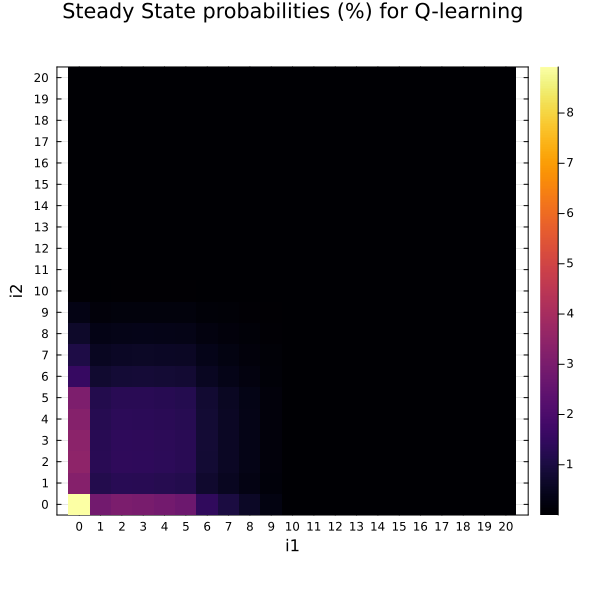

In [29]:
policy_fn = learned_policy(q_learning_solver)
heatmap_mat = compute_heatmap_policy(policy_fn)
heatmap(
    0:20, 0:20,
    heatmap_mat',
    xlabel = "i1",
    ylabel = "i2",
    title = "Steady State probabilities (%) for Q-learning",
    cbar = true,
    aspect_ratio = :equal,
    xticks = 0:1:20,
    yticks = 0:1:20,
    framestyle = :box,
    size = (600, 600)
)

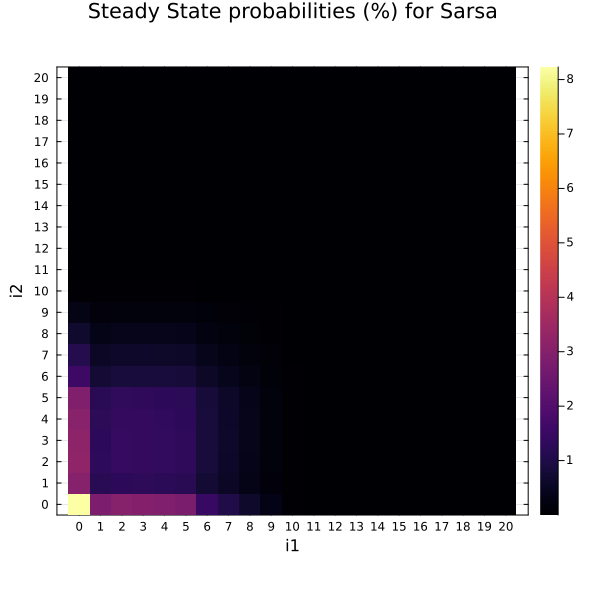

In [30]:
policy_fn = learned_policy(sarsa_solver)
heatmap_mat = compute_heatmap_policy(policy_fn)
heatmap(
    0:20, 0:20,
    heatmap_mat',
    xlabel = "i1",
    ylabel = "i2",
    title = "Steady State probabilities (%) for Sarsa",
    cbar = true,
    aspect_ratio = :equal,
    xticks = 0:1:20,
    yticks = 0:1:20,
    framestyle = :box,
    size = (600, 600)
)

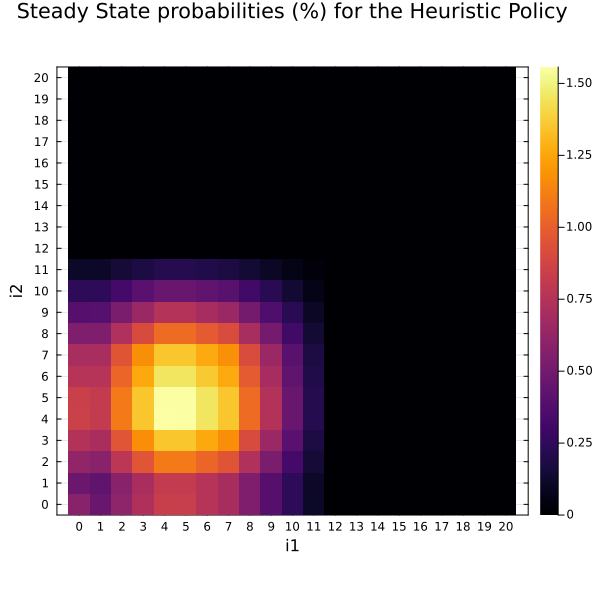

In [17]:
heatmap_mat = compute_heatmap_policy(heuristic_policy)
heatmap(
    0:20, 0:20,
    heatmap_mat',
    xlabel = "i1",
    ylabel = "i2",
    title = "Steady State probabilities (%) for the Heuristic Policy",
    cbar = true,
    aspect_ratio = :equal,
    xticks = 0:1:20,
    yticks = 0:1:20,
    framestyle = :box,
    size = (600, 600)
)

Now, let's show what the stock evolution over multiple days look like for each different policy.

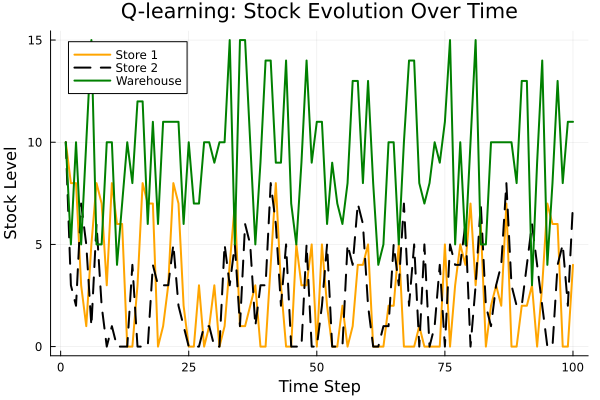

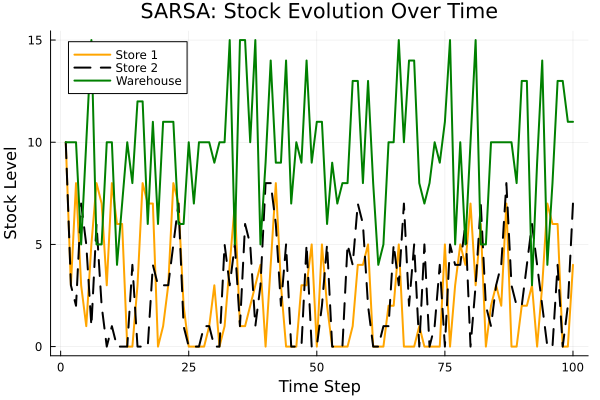

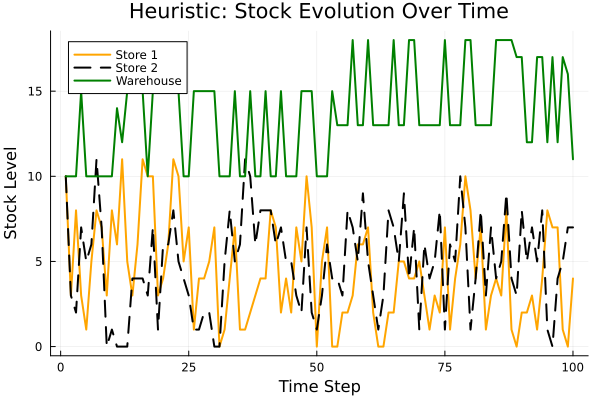

In [16]:


function plot_stock_evolution(policy_fn; num_steps=1000, seed=1234, title_str="Stock Evolution Over Time")
    rng = MersenneTwister(seed)
    initial_state = (10, 10, 10)
    sim = simulate_episode(policy_fn, initial_state, rng, num_steps)
    states = sim.states

    i1_list = [s[1] for s in states]
    i2_list = [s[2] for s in states]
    w_list  = [s[3] for s in states]

    plot(1:length(states), i1_list,
        label="Store 1", linestyle=:solid, color=:orange, lw=2)

    plot!(1:length(states), i2_list,
        label="Store 2", linestyle=:dash, color=:black, lw=2)

    plot!(1:length(states), w_list,
        label="Warehouse", linestyle=:solid, color=:green, lw=2)

    xlabel!("Time Step")
    ylabel!("Stock Level")
    title!(title_str)

    display(current())  
end

plot_stock_evolution(learned_policy(q_learning_solver);
    num_steps=100, seed=1234,
    title_str="Q-learning: Stock Evolution Over Time")

plot_stock_evolution(learned_policy(sarsa_solver);
    num_steps=100, seed=1234,
    title_str="SARSA: Stock Evolution Over Time")

plot_stock_evolution(heuristic_policy;
    num_steps=100, seed=1234,
    title_str="Heuristic: Stock Evolution Over Time")


We see that the heuristic has a clean seperation between the warehouse stock and the stores stocks. Indeed, the warehouse never has a stock below 10 in this case, while with the RL policies, its stock may fall close to 0. This indicates that, as said before, the RL policies tends to minimize the holding costs, at the cost of maybe losing a sale, while the heuristic policy will never allow that. RL policies tend to never allow more than 10 bikes in the stores, never leading to the extra cost of keeping bikes in the parking space in the case of the first store.